## 第三次讀書會專案：針對PTT軍事版以及八卦版中對於美國出兵伊朗相關文章- text embedding
### 組別：Group_3
#### 組員：
* M144020008 洪宏林
* M144020017 陳姿佑
* M144020019 顏志豪
* M144020058 黄鈞浩
* M144020002 吳俊廷
* M144020028 白茗仁
* M144020061 黃博章
* B124020008 李怡君
##### 詳細檔案可到：https://github.com/bread5555/group3_work3

#### 專案動機：
1.	國際危機下的社會： 2026年3月初，伊朗局勢成為國際焦點，短短 20 天內在 PTT 雙看板（八卦版、戰爭版）湧現逾兩千篇文章。面對遠在天邊的中東衝突，台灣網友的反應並非漠不關心，而是投射了強烈的情緒。透過情緒分析，我們能捕捉到這些隱藏在文字背後的社會集體心理狀態。

2.	數位社群的輿論場域與資訊噪音： 路討論中充斥著即時戰報、外交口水、經濟焦慮，甚至伴隨著各種立場的訊息來源（如大紀元、中央社、外電翻譯）。在動輒數千篇的文章中，分析輿論的演變軌跡與核心議題。

3.	台灣視角的在地化解讀： 解析社群在面對全球危機時的關注差異，並透過分析揭示輿論焦點是什麼。

#### 1.資料介紹
##### 資料來源：
* Python爬蟲收集PTT平台上與《伊朗》相關的文章
* 來源：戰爭版/八卦版
* 關鍵字：伊朗
* 時間： 2026/03/01~2026/04/26
* 資料筆數：共 3899篇文章

# 一、text embedding

#### 1.1 初始設定

In [1]:
#!pip install gensim
#!pip install jieba
#!pip install adjustText
#!pip install scikit-learn
#!pip install sentence_transformers
#!pip install ckip_transformers
import pandas as pd
import re
import numpy as np
from collections import defaultdict
import multiprocessing
import jieba
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager

# 設定字體
fontManager.addfont('../TaipeiSansTCBeta-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
plt.rcParams['font.size'] = '16'
import pandas as pd
import jieba
import jieba.analyse
import re
import numpy as np
from collections import defaultdict
import multiprocessing

from transformers import BertTokenizerFast, AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker
#!pip install bertopic
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec, KeyedVectors

from gensim.models import Word2Vec

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#!pip install seaborn
import seaborn as sns
import torch

#!pip install plotly
from matplotlib.font_manager import fontManager
import plotly.express as px
from adjustText import adjust_text

sns.set_style("darkgrid")

c:\Users\bread\.conda\envs\web_scraping\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\bread\.conda\envs\web_scraping\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 1.2 讀取與基本清洗

In [2]:
# 讀取檔案
df = pd.read_csv('../data/ptt_iran_20260301_0426_full.csv')
clear_df = df.copy() # 複製一份資料進行清洗，保留原始資料以供對照

# 定義並去除分析時用不到的系統與詮釋資料欄位
drop_cols = ['system_id', 'artCatagory', 'artUrl', 'artPoster', 'insertedDate','artComment','dataSource']
clear_df.drop(drop_cols, axis=1, inplace=True, errors='ignore')

# 移除內文 (artContent) 為空值的資料行
clear_df.dropna(subset=['artContent'], inplace=True)

clear_df.head(20)

,artTitle,artDate,artContent
0,[情報] ISW 伊朗更新特別報告，2026年4月25日,2026-04-26 13:21:13,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...
1,[分享] 想推翻伊朗政權 但不願川普得利,2026-04-26 05:57:04,紐時專欄作家佛里曼：想推翻伊朗政權 但不願川普得利\nhttps://www.worldjo...
2,[情報] NBC：伊朗戰爭初期成功用F-5轟炸美軍基地,2026-04-26 03:04:56,https://x.com/JimLaPorta/status/20480973242917...
3,[情報] 川普宣布暫緩與伊朗談判,2026-04-26 02:51:16,https://x.com/BarakRavid/status/20480766497117...
4,[情報] 伊朗暗示要切斷波斯灣海底電纜,2026-04-25 21:52:12,https://x.com/nexta_tv/status/2047998937148129...
5,[情報] ISW 伊朗更新特別報告，2026年4月24日,2026-04-25 13:35:58,https://tinyurl.com/26y6bh64\n\n伊朗更新特別報告，2026年...
6,Re: [情報] 川普對伊朗談判相關消息數則,2026-04-25 04:27:46,https://x.com/Acyn/status/2047651132764574035\...
7,[情報] 美國與伊朗派遣外交代表去巴基斯坦,2026-04-25 01:11:26,https://x.com/BarakRavid/status/20477148724864...
8,Re: [新聞] 別催我！被問伊朗戰爭還要打多久 川普回,2026-04-24 17:55:12,※ 引述《Lsamia (samia)》之銘言：\n: 原文來源：https://www.n...
9,[分享] 紐時：美軍在伊朗戰爭消耗高階彈藥甚鉅,2026-04-24 13:26:37,https://x.com/jonathanvswan/status/20474644719...


#### 1.3 PTT 專屬進階文字清理

In [3]:
# 建立文字前處理流程：自訂詞、同義詞、停用詞、PTT 文字清理、jieba 斷詞、資料整理與混淆矩陣繪圖函式。
# 這一格是後續分類模型的核心前處理設定，會把原始文章轉成模型可以使用的 words 欄位。

# 自訂專有名詞，讓 jieba 不會把重要詞彙切得太碎
custom_words = [
    '防衛隊', '革命衛隊', '無人機', '核設施', '哈瑪斯', '真主黨', '中東',
    '大馬士革', '德黑蘭', '哈梅內伊', '哈米尼', '霍爾木茲海峽',
    '荷姆茲海峽', '荷莫茲海峽'
]

# 同義詞統一表：把不同寫法轉成同一個標準詞
synonyms = {
    '哈梅內伊': '哈米尼',
    '霍爾木茲': '荷姆茲',
    '荷莫茲': '荷姆茲',
    '阿川': '川普',
    '川皇': '川普',
}

# 手動停用詞：移除常見但對分類幫助不大的 PTT 用語與雜訊詞
manual_stopwords = {
    '-----', '----', '連結', '嘖嘖', '醒醒', '裝睡', '衛生紙', '乳摸', '高潮',
    '新聞', '內文', '備註', '刪除', '完整', '轉載', '編輯', '張貼', '署名',
    '文章', '標題', '報導', '八卦', '看板', '作者', '時間', '來源', '內容',
    '媒體', '情況', '問題', '如題', '原因', '網址', '發信', '實業', 'cc',
    'ptt', 'gossiping', 'www', 'com', 'https', 'http', 'share', 'url', 'index',
    'html', 'bbs', 'status', '表示', '行動', '國家', '當作', '出現', '晚間',
    '政府', '目前', '請放', '最後', '違者', '未滿', '繁體', '中文字', '水桶',
    '一天', '以天', '單位', '網友', '點擊', '情報', '分享', '問卦', '討論',
    '心得', '爆卦'
}

# 載入 jieba 字典與使用者自訂詞典
jieba.set_dictionary('../dict/dict.txt')
jieba.load_userdict('../dict/user_dict.txt')
for word in custom_words:
    jieba.add_word(word)

stopwords = []
for stopword_file in ['../dict/stopwords.txt', '../dict/text_stopwords.txt']:
    with open(stopword_file, encoding='utf-8') as f:
        stopwords.extend([line.strip() for line in f if line.strip()])
stopwords = set(stopwords) | manual_stopwords


# 清理 PTT 原文，只保留適合中文斷詞與建模的主要文字
def clean_ptt_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'※\s*(發信站|文章網址|編輯).*', '', text)
    text = re.sub(r'引述《.*?》之銘言', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'^[>:]\s*', '', text, flags=re.MULTILINE)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
    text = re.sub(r'[-/=_~]{2,}', '', text)
    text = re.sub(r'[^\u4e00-\u9fa5\n]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# 將清理後文字斷詞，並移除停用詞與過短詞
def getToken(text):
    tokens = []
    for word in jieba.lcut(text):
        word = synonyms.get(word, word).strip()
        if len(word) >= 2 and word not in stopwords:
            tokens.append(word)
    return tokens


# 將原始 PTT 資料整理成模型可用的文件資料表
def prepare_ptt_documents(df, drop_missing_label=True):
    data = df[['artUrl', 'artTitle', 'artContent', 'artCatagory', 'artDate']].copy()
    subset = ['artTitle', 'artContent'] + (['artCatagory'] if drop_missing_label else [])
    data = data.dropna(subset=subset)
    data = data.drop_duplicates(subset='artUrl').copy()
    data['artDate'] = pd.to_datetime(data['artDate'], errors='coerce')
    data['title_clean'] = data['artTitle'].map(clean_ptt_text)
    data['content_clean'] = data['artContent'].map(clean_ptt_text)
    data['content'] = (data['title_clean'] + ' ' + data['content_clean']).str.strip()
    data['sentence'] = data['artContent'].str.replace(r'\n\n', '。', regex=True)
    data['sentence'] = data['sentence'].str.replace(r'\n', '', regex=True)
    data['sentence'] = data['sentence'].str.split(r'[,，。！!？?]{1,}')
    data = data.explode('sentence').reset_index(drop=True)
    data['sentence'] = data['sentence'].apply(lambda x: re.sub(r'[^\u4e00-\u9fff]+', '', str(x)))
    data = data[data['sentence'].str.len() > 0].copy()

    data['words'] = data['sentence'].apply(getToken)  # 改對 sentence 斷詞
    data = data[data['words'].str.len() > 0].copy()
    return data


Building prefix dict from c:\Users\bread\Desktop\Social_Network_Analysis_Group_3_work3\dict\dict.txt ...
Loading model from cache C:\Users\bread\AppData\Local\Temp\jieba.u29c6865baf782012cab1b9b4ce7bac9b.cache
Loading model cost 0.475 seconds.
Prefix dict has been built successfully.


In [4]:
full_docs = prepare_ptt_documents(df, drop_missing_label=True)
full_docs

,artUrl,artTitle,artContent,artCatagory,artDate,title_clean,content_clean,content,sentence,words
1,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,伊朗更新特別報告,"[伊朗, 更新, 特別, 報告]"
3,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,美國企業研究所旗下的戰爭研究所與關鍵威脅計畫正每日發布更新,"[美國, 企業, 研究所, 旗下, 戰爭, 研究所, 關鍵, 威脅, 計畫, 每日, 發布,..."
4,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,以提供對與伊朗戰爭的分析,"[提供, 伊朗, 戰爭, 分析]"
5,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,這些更新聚焦於美國與以色列對伊朗的打擊,"[更新, 聚焦, 美國, 以色列, 伊朗, 打擊]"
6,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,以及伊朗與抵抗軸心對這些打擊的回應,"[伊朗, 抵抗, 軸心, 打擊, 回應]"
...,...,...,...,...,...,...,...,...,...,...
134670,https://www.ptt.cc/bbs/Gossiping/M.1772294520....,[問卦] 以色列說伊朗精神導師哈米尼已身亡,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,Gossiping,2026-03-01 00:01:58,以色列說伊朗精神導師哈米尼已身亡,以色列電視台頻道快訊說 伊朗精神導師哈米尼已身亡 所以戰爭要結束了嗎 才打幾小時說,以色列說伊朗精神導師哈米尼已身亡 以色列電視台頻道快訊說 伊朗精神導師哈米尼已身亡 所以戰爭...,以色列電視台頻道快訊說伊朗精神導師哈米尼已身亡,"[以色列, 電視台, 頻道, 快訊, 伊朗, 精神, 導師, 哈米尼, 身亡]"
134671,https://www.ptt.cc/bbs/Gossiping/M.1772294520....,[問卦] 以色列說伊朗精神導師哈米尼已身亡,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,Gossiping,2026-03-01 00:01:58,以色列說伊朗精神導師哈米尼已身亡,以色列電視台頻道快訊說 伊朗精神導師哈米尼已身亡 所以戰爭要結束了嗎 才打幾小時說,以色列說伊朗精神導師哈米尼已身亡 以色列電視台頻道快訊說 伊朗精神導師哈米尼已身亡 所以戰爭...,所以戰爭要結束了嗎,"[戰爭, 結束]"
134672,https://www.ptt.cc/bbs/Gossiping/M.1772294520....,[問卦] 以色列說伊朗精神導師哈米尼已身亡,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,Gossiping,2026-03-01 00:01:58,以色列說伊朗精神導師哈米尼已身亡,以色列電視台頻道快訊說 伊朗精神導師哈米尼已身亡 所以戰爭要結束了嗎 才打幾小時說,以色列說伊朗精神導師哈米尼已身亡 以色列電視台頻道快訊說 伊朗精神導師哈米尼已身亡 所以戰爭...,才打幾小時說,[幾小時]
134673,https://www.ptt.cc/bbs/Gossiping/M.1772294520....,[問卦] 以色列說伊朗精神導師哈米尼已身亡,https://i.imgur.com/FrMBP3e.jpeg\n\n以色列電視台12頻道...,Gossiping,2026-03-01 00:01:58,以色列說伊朗精神導師哈米尼已身亡,以色列電視台頻道快訊說 伊朗精神導師哈米尼已身亡 所以戰爭要結束了嗎 才打幾小時說,以色列說伊朗精神導師哈米尼已身亡 以色列電視台頻道快訊說 伊朗精神導師哈米尼已身亡 所以戰爭...,發信站批踢踢實業坊,"[站批, 踢踢]"


### word2vec

In [5]:
sents = full_docs['words'].to_list()
#將斷詞結果中的常見詞組合成一個詞，min_count=1 表示只要出現一次就考慮組合，threshold=1000 表示組合的嚴格程度，數值越大越嚴格
bigrams = Phrases(sents,min_count=1, threshold=1000)
bigram_phrasers = Phraser(bigrams) #將斷詞放入 bigram_phrasers 中，讓它學習哪些詞組合成一個詞
full_docs['word_list_bigrams'] = list(bigram_phrasers[sents]) #將斷詞結果中的常見詞組合成一個詞，並存入新的欄位 word_list_bigrams 中

full_docs.head()

,artUrl,artTitle,artContent,artCatagory,artDate,title_clean,content_clean,content,sentence,words,word_list_bigrams
1,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,伊朗更新特別報告,"[伊朗, 更新, 特別, 報告]","[伊朗, 更新, 特別, 報告]"
3,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,美國企業研究所旗下的戰爭研究所與關鍵威脅計畫正每日發布更新,"[美國, 企業, 研究所, 旗下, 戰爭, 研究所, 關鍵, 威脅, 計畫, 每日, 發布,...","[美國, 企業, 研究所, 旗下, 戰爭, 研究所, 關鍵, 威脅, 計畫, 每日, 發布,..."
4,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,以提供對與伊朗戰爭的分析,"[提供, 伊朗, 戰爭, 分析]","[提供, 伊朗, 戰爭, 分析]"
5,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,這些更新聚焦於美國與以色列對伊朗的打擊,"[更新, 聚焦, 美國, 以色列, 伊朗, 打擊]","[更新, 聚焦, 美國, 以色列, 伊朗, 打擊]"
6,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,以及伊朗與抵抗軸心對這些打擊的回應,"[伊朗, 抵抗, 軸心, 打擊, 回應]","[伊朗, 抵抗_軸心, 打擊, 回應]"


In [6]:
#計算詞頻
word_freq = defaultdict(int) # 使用 defaultdict 來計算詞頻，預設值為 0
sents = full_docs['word_list_bigrams'].tolist()
for sent in sents: # sent 中的每個單詞
    for i in sent: # i 是單詞中的每個字
        word_freq[i] += 1 # 將每個單詞的出現次數加到 word_freq 中

In [7]:
print(f"total unique words in sentences: {len(word_freq)}")
sorted(word_freq, key=word_freq.get, reverse=True)[:10] # 印出出現頻率最高的前 10 個詞

total unique words in sentences: 39033


['伊朗', '美國', '川普', '以色列', '臺灣', '戰爭', '踢踢', '站批', '攻擊', '美軍']

In [8]:
print(f"sentence number of corpus: {len(sents)}") # 印出資料中句子數量
i = 0
for sent in sents:
    i = i + len(sent)
print(f"average length of sentences: {i/len(sents)}") # 印出資料中句子平均長度

sentence number of corpus: 120129
average length of sentences: 4.575606223309942


#### Word2Vec 計算

In [9]:
%env PYTHONHASHSEED=2025

env: PYTHONHASHSEED=2025


In [10]:
# 查看機器的core
cores = multiprocessing.cpu_count()
print(f"number of cores: {cores}")

number of cores: 16


In [11]:
# 建立模型
w2v_model = Word2Vec(sents,
                     min_count=30,  # 小於30次的字不考慮
                     window=2,  # 往左右各2的距離，考慮該詞的上下文
                     vector_size=128,  # vector 的維度
                     sample=0.005,  # 愈小的話，字頻高的字會不容易被選到
                     alpha=0.001,  # learning rate
                     min_alpha=0.0005,  # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha
                     negative=0,
                     workers=cores-1,  # 用的cpu資源
                     seed=8787,
                     sg = 1,  # 0/1 是否使用skip gram ，0是cbow，1是skip gram（用中心詞來預測上下文），
                     epochs= 30,
                     hs=1 ,  # hierarchical softmax （用於加速訓練）
                     )

In [12]:
w2v_model.wv.most_similar('伊朗',topn=10) # 印出與「伊朗」最相似的前10個詞

[('德黑蘭', 0.6024727821350098),
 ('現在', 0.4825764298439026),
 ('繼續', 0.44949841499328613),
 ('斬首', 0.3942626416683197),
 ('之後', 0.39353978633880615),
 ('直接', 0.3854232132434845),
 ('中國', 0.3512427806854248),
 ('似乎', 0.3477784991264343),
 ('轟炸', 0.34269487857818604),
 ('推翻', 0.3361527621746063)]

In [13]:
w2v_model.wv.most_similar('美國',topn=10)

[('俄羅斯', 0.4804518222808838),
 ('米國', 0.4605850577354431),
 ('中國', 0.4574577212333679),
 ('繼續', 0.4533565938472748),
 ('現在', 0.450975626707077),
 ('美軍', 0.4261719882488251),
 ('烏克蘭', 0.41854095458984375),
 ('歐洲', 0.40659549832344055),
 ('美帝', 0.391890287399292),
 ('委內瑞拉', 0.3881891667842865)]

In [14]:
w2v_model.wv.most_similar(['伊朗','美國'],topn=10) # 印出與「伊朗」和「美國」最相似的前10個詞，這裡是用兩個詞的平均向量來找相似詞

[('現在', 0.5861263871192932),
 ('繼續', 0.5668535232543945),
 ('中國', 0.5077389478683472),
 ('俄羅斯', 0.4868331253528595),
 ('去年', 0.44488775730133057),
 ('中共', 0.43021562695503235),
 ('烏克蘭', 0.4287784695625305),
 ('台灣', 0.4226148724555969),
 ('一直', 0.41673925518989563),
 ('準備', 0.4113904535770416)]

In [15]:
# 跟兩個字最不相關
w2v_model.wv.most_similar(negative=['伊朗','美國'],topn=10)

[('顯示', 0.26219138503074646),
 ('傷亡', 0.22798384726047516),
 ('踢踢', 0.19869457185268402),
 ('風險', 0.1979871243238449),
 ('存在', 0.19635994732379913),
 ('人員', 0.18761755526065826),
 ('變化', 0.18575672805309296),
 ('中心', 0.18283504247665405),
 ('過長', 0.17570564150810242),
 ('造成', 0.1733143925666809)]

In [16]:
# 計算兩個字之間的關係
w2v_model.wv.similarity("伊朗","美國")

np.float32(0.26842394)

In [17]:
w2v_model.wv.similarity("美國","川普")

np.float32(0.36643147)

In [18]:
w2v_model.wv.doesnt_match(["美國","川普", "攻擊"]) # 印出與「美國」、「川普」、「攻擊」最不相關的詞，這裡是用三個詞的平均向量來找不相關詞

'攻擊'

In [19]:
# 相對關係
w2v_model.wv.most_similar(positive=["伊朗"], negative=["戰爭"], topn=5) # 印出與「伊朗」最相似但與「戰爭」不相似的前5個詞，這裡是用「伊朗」的向量減去「戰爭」的向量來找相似詞

[('德黑蘭', 0.46322473883628845),
 ('包括', 0.41611340641975403),
 ('革命衛隊', 0.3987419307231903),
 ('船隻', 0.3613889217376709),
 ('透過', 0.3560175597667694)]

In [20]:
# 取得所有的字
words = w2v_model.wv.key_to_index.keys()

#### 視覺化字之間的關係及將字做分群

In [21]:
# 降維：利用PCA tSNE

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 25,learning_rate = 400): # mat 是要降維的矩陣，method 是降維方法，dim 是降維後的維度，perplexity 和 learning_rate 是 tSNE 的參數

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0), # PCA 的參數，n_components 是降維後的維度，iterated_power 是 power iteration 的次數
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate), # tSNE 的參數，n_components 是降維後的維度
    }
    new_feat = method_dict[method].fit_transform(mat) # 將 mat 這個矩陣降維成 dim 維，並存入 new_feat 中

    return new_feat


In [22]:
# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        vecs.append(model.wv[i])
    return np.vstack(vecs)


In [23]:
getVecs(w2v_model,['伊朗','戰爭']) # 印出「伊朗」和「戰爭」的向量，這裡是用 model.wv[i] 來取得每個詞的向量，並將它們堆疊成一個矩陣

array([[-1.32335737e-01,  7.91735202e-02,  7.63251353e-03,
        -1.87130198e-01, -1.25684261e-01, -1.25173363e-03,
         1.73016626e-04, -7.45323524e-02,  4.78158116e-01,
         1.67143196e-01, -2.08994493e-01,  3.14784825e-01,
         4.48565790e-03, -4.58046943e-01, -1.54559284e-01,
         2.53686339e-01, -3.25486548e-02,  5.37403934e-02,
         2.82647312e-01,  1.73787162e-01,  2.25824669e-01,
         1.09809346e-01,  4.95047905e-02,  2.60531992e-01,
         6.23958185e-02,  5.38156591e-02,  2.63516188e-01,
         4.95489180e-01,  4.34172638e-02,  3.78553331e-01,
         1.02610856e-01, -2.33065505e-02,  4.00853187e-01,
        -1.56223346e-02,  5.34352541e-01, -3.71908277e-01,
        -4.73906279e-01, -1.97219476e-01, -2.49402434e-01,
        -3.79614919e-01, -2.27976263e-01, -1.37412295e-01,
         1.50997162e-01, -2.96618342e-01,  2.09267475e-02,
         3.98647457e-01,  4.28524390e-02,  1.03630520e-01,
         6.96287453e-02, -4.47936922e-01, -3.16777110e-0

In [24]:
# 擴展相似的字詞，把每個字詞的相似字詞都放在一起，並去除重複的字詞
def expandPosWord(model, words:list, top_n:int, split = True):

    if split == False:
        wp = model.wv.most_similar(words,topn = top_n)
        return wp
    expand = []

    for w in words:
        wp = model.wv.most_similar(w,topn = top_n)
        for i in wp:
            expand.append(i[0])

    return list(set(expand))


In [25]:
expandPosWord(w2v_model, ['伊朗','美國'], top_n=10, split=True) # 印出與「伊朗」和「美國」最相似的前10個詞，這裡是用兩個詞的平均向量來找相似詞，並將每個詞的相似詞都放在一起，最後去除重複的詞

['似乎',
 '中國',
 '米國',
 '美軍',
 '德黑蘭',
 '轟炸',
 '俄羅斯',
 '烏克蘭',
 '歐洲',
 '美帝',
 '之後',
 '推翻',
 '現在',
 '委內瑞拉',
 '斬首',
 '直接',
 '繼續']

In [26]:
# 畫出兩維的散佈圖
def plotScatter(vec_df, title="詞向量分佈圖", output_html="scatter_2d.html"):
    """
    vec_df: 字詞及其兩個維度的值
    """
    df = vec_df.copy()

    # 計算每個點到中心的距離，標記前 30 個離群詞
    cx, cy = df['dim1'].mean(), df['dim2'].mean()
    df['dist'] = ((df['dim1'] - cx)**2 + (df['dim2'] - cy)**2) ** 0.5
    top_n = df.nlargest(30, 'dist').index
    df['label'] = ''
    df.loc[top_n, 'label'] = df.loc[top_n, 'word']

    fig = px.scatter(
        df,
        x='dim1',
        y='dim2',
        text='label',          # 只顯示離群點的文字
        hover_name='word',     # hover 時顯示詞語
        hover_data={'dim1': ':.2f', 'dim2': ':.2f', 'label': False},
        color='dist',          # 用距離上色
        color_continuous_scale='Viridis',
        title=title,
        width=900,
        height=800,
    )

    fig.update_traces(
        textposition='top right',
        textfont=dict(size=11, color='black'),
        marker=dict(size=6, opacity=0.75),
    )

    fig.update_layout(
        font_family='Arial Unicode MS',
        title_font_size=20,
        coloraxis_colorbar_title='離群程度',
        plot_bgcolor='#f0f4f8',
        paper_bgcolor='white',
        xaxis=dict(showgrid=True, gridcolor='white'),
        yaxis=dict(showgrid=True, gridcolor='white'),
    )

    fig.write_html(output_html)
    print(f"已輸出 HTML：{output_html}")
    fig.show()

# 畫出三維的散佈圖
def plotScatter3D(vec_df, output_html="scatter_3d.html"):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'
    fig = px.scatter_3d(
        vec_df,'dim1','dim2','dim3',text = 'word',width=800, height=800,color = 'color',size = 'size'

    )
    fig.write_html(output_html)
    print(f"已輸出 HTML：{output_html}")
    fig.show()

In [27]:
sample_words = np.random.choice(list(words),300,replace=False).tolist() # 從所有的字詞中隨機選擇300個字詞，並將它們放在 sample_words 中，
feat = getVecs(model=w2v_model,words=sample_words)
print(feat.shape)
new_feat = reduceDim(feat,method='TSNE',perplexity=20,learning_rate = 800) # 將 feat 這個矩陣降維成 2 維，並存入 new_feat 中
print(new_feat.shape)

(300, 128)
(300, 2)


In [28]:
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0], #dim1 是降維後的第一個維度
    "dim2":new_feat[:,1], #dim2 是降維後的第二個維度
})

In [29]:
plotScatter(word_df)

已輸出 HTML：scatter_2d.html


In [30]:
new_feat = reduceDim(feat,dim = 3,method = 'PCA' ) # 將 feat 這個矩陣降維成 3 維，並存入 new_feat 中
print(new_feat.shape)
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
    "dim3":new_feat[:,2],
})
plotScatter3D(word_df)

(300, 3)
已輸出 HTML：scatter_3d.html


#### 字分群

In [31]:
from sklearn.cluster import KMeans
#from sklearn_extra.cluster import KMedoids

def cluster(X,method = 'kmeans',n = 2):
    #method_dict = {'kmeans':KMeans(n_clusters=n, random_state=0),
    #               'kmedoids':KMedoids(n_clusters=n, random_state=0) }
    method_dict = {'kmeans':KMeans(n_clusters=n, random_state=0)} #使用 KMeans 來做分群，n_clusters 是分成幾群，random_state 是隨機種子
    method_dict[method].fit(X)
    result = method_dict[method].predict(X)
    return result

In [32]:
new_feat = reduceDim(feat,method='PCA',dim = 20) # 將 feat 這個矩陣降維成 20 維，並存入 new_feat 中
d3_feat = reduceDim(feat,method='PCA',dim = 3) # 將 feat 這個矩陣降維成 3 維，並存入 d3_feat 中
word_df = pd.DataFrame({
    "word":sample_words,
    "color":cluster(new_feat,n=4), # 將每個詞的顏色設為其所屬的群集,這裡是用降維後的 20 維向量來做分群，分成 4 群
    "dim1":d3_feat[:,0],
    "dim2":d3_feat[:,1],
    "dim3":d3_feat[:,2],

})
plotScatter3D(word_df, output_html="scatter_3d_cluster.html") # 畫出三維的散佈圖，並將其輸出為 scatter_3d_cluster.html

已輸出 HTML：scatter_3d_cluster.html


#### 延伸應用：相似文件分析

In [33]:
from sentence_transformers import SentenceTransformer, models, util

C:\Users\bread\AppData\Local\Temp\ipykernel_13292\593637398.py:1: DeprecationWarning: Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.
  from sentence_transformers import SentenceTransformer, models, util


In [34]:
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'}) # 添加 [PAD] 標記，並將其設為填充標記，目的為了讓模型能夠處理不同長度的輸入，避免因為缺乏填充標記而出現錯誤

0

In [35]:
#把df中給的自訂順序 ，另外給一個欄位叫做system_id
clear_df['system_id'] = range(len(clear_df))
df_similar = clear_df[['system_id','artTitle', 'artContent']]
# 將 artContent 中的非中文字符刪除
df_similar['artContent'] = df_similar['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

df_similar.head(5)

,system_id,artTitle,artContent
0,0,[情報] ISW 伊朗更新特別報告，2026年4月25日,伊朗更新特別報告年月日美國企業研究所旗下的戰爭研究所與關鍵威脅計畫正每日發布更新以提供對與伊...
1,1,[分享] 想推翻伊朗政權 但不願川普得利,紐時專欄作家佛里曼想推翻伊朗政權但不願川普得利世界新聞網王若馨即時報導這是紐時專欄作家佛里曼...
2,2,[情報] NBC：伊朗戰爭初期成功用F-5轟炸美軍基地,報導美國官員國會幕僚和其他相關人士證實本次伊朗戰爭中美軍基地與裝備蒙受損失遠高於官方公開承認...
3,3,[情報] 川普宣布暫緩與伊朗談判,川普接受訪問時表示已經喊停原定派和再次前往巴基斯坦的計畫川普說伊朗隨時可以打電話給美國政府自...
4,4,[情報] 伊朗暗示要切斷波斯灣海底電纜,伊朗暗示將襲擊網路基礎設施整個區域面臨威脅與伊朗安全部隊關係密切的塔斯尼姆通訊社發布了一張海...


In [36]:
corpus_embeddings = bert_ch.encode( # 將 artContent 轉換為 BERT 的embedding向量
    df_similar['artContent'].tolist(),
    convert_to_tensor=True,
    batch_size=32
)

In [37]:
query_num = 1 # 指定文章

# 找出與該文章最相似的前五篇文章
top_k = 5


query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True) # 將查詢文章轉換為BERT的embedding向量

cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0] #計算餘弦相似度，找出相似的文章
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: [分享] 想推翻伊朗政權 但不願川普得利

 資料集中前五相似的文章:
[分享] 想推翻伊朗政權 但不願川普得利 (Score: 1.0000)
[情報] 德國另類選擇黨批評川普空襲伊朗是好戰 (Score: 0.9833)
Re: [新聞] 美國重量級學者米爾斯海默：美國在伊朗 (Score: 0.9831)
[分享] 紐約時代廣場湧入民眾聲援伊朗被炸 (Score: 0.9823)
[新聞] 眼看美國深陷伊朗泥淖，中國為何一語不發 (Score: 0.9823)






In [38]:
query_num = 10 # 指定文章

# Find the closest 5 sentences of the corpus for each query sentence based on cosine similarity
top_k = 5


query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: [新聞] 別催我！被問伊朗戰爭還要打多久　川普回

 資料集中前五相似的文章:
[新聞] 別催我！被問伊朗戰爭還要打多久　川普回 (Score: 1.0000)
[新聞] 別催我！被問伊朗戰爭還要打多久　川普不 (Score: 0.9967)
Re: [新聞] 別催我！被問伊朗戰爭還要打多久　川普回 (Score: 0.9881)
Re: [新聞] 川普自爆伊朗想談但他拒絕停火原因！稱「 (Score: 0.9860)
Re: [分享] 川普以珍珠港事件來形容打伊朗的出其不意 (Score: 0.9842)






### classification with embedding

In [39]:
ptt=df[['artTitle', 'artContent','artUrl','artCatagory']]
ptt.head()

,artTitle,artContent,artUrl,artCatagory
0,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,https://www.ptt.cc/bbs/Military/M.1777180876.A...,Military
1,[分享] 想推翻伊朗政權 但不願川普得利,紐時專欄作家佛里曼：想推翻伊朗政權 但不願川普得利\nhttps://www.worldjo...,https://www.ptt.cc/bbs/Military/M.1777154229.A...,Military
2,[情報] NBC：伊朗戰爭初期成功用F-5轟炸美軍基地,https://x.com/JimLaPorta/status/20480973242917...,https://www.ptt.cc/bbs/Military/M.1777143899.A...,Military
3,[情報] 川普宣布暫緩與伊朗談判,https://x.com/BarakRavid/status/20480766497117...,https://www.ptt.cc/bbs/Military/M.1777143078.A...,Military
4,[情報] 伊朗暗示要切斷波斯灣海底電纜,https://x.com/nexta_tv/status/2047998937148129...,https://www.ptt.cc/bbs/Military/M.1777125135.A...,Military


In [40]:
ptt['artContent'] = ptt['artContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

ptt.head(5)

,artTitle,artContent,artUrl,artCatagory
0,[情報] ISW 伊朗更新特別報告，2026年4月25日,伊朗更新特別報告年月日美國企業研究所旗下的戰爭研究所與關鍵威脅計畫正每日發布更新以提供對與伊...,https://www.ptt.cc/bbs/Military/M.1777180876.A...,Military
1,[分享] 想推翻伊朗政權 但不願川普得利,紐時專欄作家佛里曼想推翻伊朗政權但不願川普得利世界新聞網王若馨即時報導這是紐時專欄作家佛里曼...,https://www.ptt.cc/bbs/Military/M.1777154229.A...,Military
2,[情報] NBC：伊朗戰爭初期成功用F-5轟炸美軍基地,報導美國官員國會幕僚和其他相關人士證實本次伊朗戰爭中美軍基地與裝備蒙受損失遠高於官方公開承認...,https://www.ptt.cc/bbs/Military/M.1777143899.A...,Military
3,[情報] 川普宣布暫緩與伊朗談判,川普接受訪問時表示已經喊停原定派和再次前往巴基斯坦的計畫川普說伊朗隨時可以打電話給美國政府自...,https://www.ptt.cc/bbs/Military/M.1777143078.A...,Military
4,[情報] 伊朗暗示要切斷波斯灣海底電纜,伊朗暗示將襲擊網路基礎設施整個區域面臨威脅與伊朗安全部隊關係密切的塔斯尼姆通訊社發布了一張海...,https://www.ptt.cc/bbs/Military/M.1777125135.A...,Military


In [41]:
ptt["embeddings"] = ptt.artContent.apply(lambda x: bert_ch.encode(x)) # 將 artContent 轉換為 BERT 的embedding向量
ptt.head(3)

,artTitle,artContent,artUrl,artCatagory,embeddings
0,[情報] ISW 伊朗更新特別報告，2026年4月25日,伊朗更新特別報告年月日美國企業研究所旗下的戰爭研究所與關鍵威脅計畫正每日發布更新以提供對與伊...,https://www.ptt.cc/bbs/Military/M.1777180876.A...,Military,"[0.35180783, -0.24355015, -0.55363303, 0.05619..."
1,[分享] 想推翻伊朗政權 但不願川普得利,紐時專欄作家佛里曼想推翻伊朗政權但不願川普得利世界新聞網王若馨即時報導這是紐時專欄作家佛里曼...,https://www.ptt.cc/bbs/Military/M.1777154229.A...,Military,"[0.43619195, -0.23550951, -0.32765114, 0.00389..."
2,[情報] NBC：伊朗戰爭初期成功用F-5轟炸美軍基地,報導美國官員國會幕僚和其他相關人士證實本次伊朗戰爭中美軍基地與裝備蒙受損失遠高於官方公開承認...,https://www.ptt.cc/bbs/Military/M.1777143899.A...,Military,"[0.21170229, -0.2463372, -0.39774114, 0.135754..."


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data = ptt.copy()

X = data["embeddings"].apply(pd.Series)
y = data["artCatagory"]

# 把整個資料集七三切
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=777
)

print(X_train.head())
print(y_train.head())

           0         1         2         3         4         5         6    \
1787  0.430183  0.067261 -0.117428  0.446033  0.072802 -0.264616  0.143066   
2011  0.468392 -0.066884 -0.366704 -0.016572 -0.049414  0.001273 -0.164238   
602   0.533546 -0.358010 -0.254745  0.093630 -0.005506  0.116571 -0.169973   
963   0.453002 -0.023420 -0.562313 -0.136163  0.080202  0.089208 -0.233095   
3882  0.469136 -0.114184 -0.236033  0.398485 -0.083678 -0.197133  0.088014   

           7         8         9    ...       758       759       760  \
1787  0.368814 -0.203445 -0.094540  ...  0.189171  0.079657  0.163517   
2011  0.091379 -0.297705 -0.233087  ... -0.011725 -0.288512  0.203678   
602   0.241259 -0.395791  0.033733  ...  0.117947 -0.244297  0.005200   
963   0.145147 -0.035397 -0.352679  ... -0.005322 -0.175794  0.105372   
3882  0.314434 -0.193511 -0.036932  ...  0.035858 -0.136204  0.121383   

           761       762       763       764       765       766       767  
1787 -0.295667 

In [45]:
clf = LogisticRegression()
clf.fit(X_train, y_train) # 訓練模型
clf

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
y_pred = clf.predict(X_test)
y_pred_proba = clf.predict_proba(X_test)
print(y_pred[:10])

['Military' 'Gossiping' 'Gossiping' 'Gossiping' 'Military' 'Military'
 'Gossiping' 'Gossiping' 'Gossiping' 'Gossiping']


In [47]:
from sklearn.metrics import classification_report
## Accuracy, Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   Gossiping       0.89      0.91      0.90       835
    Military       0.76      0.70      0.73       335

    accuracy                           0.85      1170
   macro avg       0.82      0.81      0.82      1170
weighted avg       0.85      0.85      0.85      1170



---

## NER 與情緒分析區段說明

以下區段包含 NER 實體辨識、ORG/PERSON 高頻詞圖，以及情緒模型輸出檢查。


In [48]:
# 建立輸出資料夾與固定參數，讓表格與圖片可以被重複使用。
from pathlib import Path
from IPython.display import display, Image

RANDOM_STATE = 42
SAMPLE_SIZE = 6000

OUTPUT_DIR = Path("project3_saved_outputs")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 使用 pickle 儲存 DataFrame
def load_pickle(path):
    return pd.read_pickle(path)

def save_pickle(obj, path):
    obj.to_pickle(path)
    return obj

# 初始化 CKIP 工具。device=0 使用 GPU；device=-1 使用 CPU，但速度會較慢。
# Mac 使用者若有 MPS，也可依環境調整 device。
ws_driver  = CkipWordSegmenter(model_name="ckiplab/bert-base-chinese-ws", device=0)   # 斷詞
pos_driver = CkipPosTagger(model_name="ckiplab/bert-base-chinese-pos", device=0)       # 詞性標記
ner_driver = CkipNerChunker(model_name="ckiplab/bert-base-chinese-ner", device=0)      # 命名實體辨識


### 功能說明：CKIP 斷詞、詞性標記與 NER 實體辨識

這個儲存格會從已斷句的 `full_docs` 中固定抽取最多 6000 句，進行 CKIP 斷詞、詞性標記與 NER。為了避免每次報告時結果不同，程式會先檢查資料夾中是否已有 `ner_results.pkl`；若有就直接讀取，若沒有才重新跑模型並儲存。

得到每一句話的斷詞詞性結果與辨識出的實體清單，後續可用來統計人物、組織、地名等高頻詞。


In [49]:
# NER 結果儲存路徑。若檔案已存在，優先讀取，避免每次重新跑 CKIP。
ner_results_path = TABLE_DIR / "ner_results.pkl"

if ner_results_path.exists():
    print(f"已找到既有 NER 結果，直接讀取：{ner_results_path}")
    ner_results = load_pickle(ner_results_path)
else:
    sample_size = min(SAMPLE_SIZE, len(full_docs))
    sampled_df = full_docs.sample(n=sample_size, random_state=RANDOM_STATE)

    text = sampled_df["sentence"].dropna().astype(str).tolist()
    print(f"原始資料總共: {len(full_docs)} 句")
    print(f"本次抽樣處理: {len(text)} 句")

    # 執行 CKIP 斷詞、詞性標記與 NER。
    ws = ws_driver(text)
    pos = pos_driver(ws)
    ner = ner_driver(text)

    def pack_ws_pos_sentece(sentence_ws, sentence_pos):
        # 將斷詞結果與詞性標記合併，方便人工檢查。
        assert len(sentence_ws) == len(sentence_pos)
        res = []
        for word_ws, word_pos in zip(sentence_ws, sentence_pos):
            res.append(f"{word_ws}({word_pos})")
        return "　".join(res)

    sentences, packed_sentences, entities = [], [], []

    for sentence, sentence_ws, sentence_pos, sentence_ner in zip(text, ws, pos, ner):
        sentences.append(sentence)
        packed_sentences.append(pack_ws_pos_sentece(sentence_ws, sentence_pos))
        entities.append([str(entity) for entity in sentence_ner])

    ner_results = pd.DataFrame({
        "sentence": sentences,
        "packed_sentence": packed_sentences,
        "entities": entities
    })

    # 將 NER 結果存成 pickle，下次可直接讀取。
    save_pickle(ner_results, ner_results_path)
    print(f"NER 結果已儲存：{ner_results_path}")

ner_results.head(10)


已找到既有 NER 結果，直接讀取：project3_saved_outputs\tables\ner_results.pkl


,sentence,packed_sentence,entities
0,持續在黎巴嫩南部進行地面行動,持續(VL) 在(P) 黎巴嫩(Nc) 南部(Ncd) 進行(VC) 地面(Nc) 行動(Na),"[NerToken(word='黎巴嫩', ner='GPE', idx=(3, 6))]"
1,戰死就算了,戰死(VH) 就(D) 算(VH) 了(T),[]
2,伊朗政府的回應則是指控志工為以色列與美國從事間諜活動,伊朗(Nc) 政府(Na) 的(DE) 回應(VC) 則(D) 是(SHI) 指控(VE) ...,"[NerToken(word='伊朗', ner='NORP', idx=(0, 2)), ..."
3,美國反恐負責人請辭無法昧著良心支持伊朗戰爭,美國(Nc) 反(VC) 恐(Na) 負責人(Na) 請辭(VA) 無法(D) 昧著良心(V...,"[NerToken(word='美國', ner='GPE', idx=(0, 2)), N..."
4,敵方媒體操作透過針對人民的心智與靈魂,敵方(Na) 媒體(Na) 操作(VC) 透過(P) 針對(P) 人民(Na) 的(DE) ...,[]
5,而這些系統的數量是有限的,而(Cbb) 這些(Neqa) 系統(Na) 的(DE) 數量(Na) 是(SHI) 有限(...,[]
6,據官員表示,據(P) 官員(Na) 表示(VE),[]
7,為什麼對委內瑞拉是斬首行動,為什麼(D) 對(P) 委內瑞拉(Nc) 是(SHI) 斬首(Nv) 行動(Na),"[NerToken(word='委內瑞拉', ner='GPE', idx=(4, 8))]"
8,他更傾向於完全不採取軍事打擊,他(Nh) 更(Dfa) 傾向於(VL) 完全(D) 不(D) 採取(VC) 軍事(Na) ...,[]
9,美國只動用不到的軍事力量,美國(Nc) 只(Da) 動用(VC) 不(D) 到(VC) 的(DE) 軍事(Na) 力量...,"[NerToken(word='美國', ner='GPE', idx=(0, 2))]"


### 功能說明：將 NER 實體結果攤平成表格

CKIP 的 NER 結果原本是每個句子一個實體清單。這個儲存格會把每個實體拆成一列。


In [50]:
entities_df_path = TABLE_DIR / "entities_df.pkl"

if entities_df_path.exists():
    print(f"已找到既有 entities_df，直接讀取：{entities_df_path}")
    entities_df = load_pickle(entities_df_path)
else:
    all_entities = []

    # 遍歷每一句的 NER 清單，把每個實體拆成獨立一列。
    for _, row in ner_results.iterrows():
        sentence = row["sentence"]
        entity_list = row["entities"]

        if isinstance(entity_list, list):
            for ent in entity_list:
                # CKIP 的實體字串格式類似：NerToken(word='美軍', ner='ORG', idx=(0, 2))
                match = re.match(r"NerToken\(word='(.*?)', ner='(.*?)', idx=\((\d+), (\d+)\)\)", ent)
                if match:
                    word, ner, idx_start, idx_end = match.groups()
                    all_entities.append({
                        "sentence": sentence,
                        "word": word,
                        "ner": ner,
                        "idx": (int(idx_start), int(idx_end))
                    })

    entities_df = pd.DataFrame(all_entities)

    #將展平後的實體表格存成 pickle。
    save_pickle(entities_df, entities_df_path)
    print(f"entities_df 已儲存：{entities_df_path}")

entities_df.head(10)


已找到既有 entities_df，直接讀取：project3_saved_outputs\tables\entities_df.pkl


,sentence,word,ner,idx
0,持續在黎巴嫩南部進行地面行動,黎巴嫩,GPE,"(3, 6)"
1,伊朗政府的回應則是指控志工為以色列與美國從事間諜活動,伊朗,NORP,"(0, 2)"
2,伊朗政府的回應則是指控志工為以色列與美國從事間諜活動,以色列,GPE,"(14, 17)"
3,伊朗政府的回應則是指控志工為以色列與美國從事間諜活動,美國,GPE,"(18, 20)"
4,美國反恐負責人請辭無法昧著良心支持伊朗戰爭,美國,GPE,"(0, 2)"
5,美國反恐負責人請辭無法昧著良心支持伊朗戰爭,伊朗戰爭,EVENT,"(17, 21)"
6,為什麼對委內瑞拉是斬首行動,委內瑞拉,GPE,"(4, 8)"
7,美國只動用不到的軍事力量,美國,GPE,"(0, 2)"
8,自於月日美東時間下午時的上次資料截止以來,月日,DATE,"(2, 4)"
9,自於月日美東時間下午時的上次資料截止以來,美東時間下午時,TIME,"(4, 11)"


### 功能說明：檢查 NER 類別

這個儲存格用來查看 CKIP 模型在資料中辨識出哪些 NER 類別，例如 ORG、PERSON、GPE(地理) 等。


In [51]:
# 檢查目前資料中包含哪些 NER 類別。
entities_df["ner"].unique()


<StringArray>
[        'GPE',        'NORP',       'EVENT',        'DATE',        'TIME',
         'LOC',      'PERSON',    'CARDINAL',         'ORG',       'MONEY',
    'QUANTITY',         'FAC',     'ORDINAL',     'PRODUCT',     'PERCENT',
         'LAW',    'LANGUAGE', 'WORK_OF_ART']
Length: 18, dtype: str

### 功能說明：ORG 類別前十高頻詞圖

這個儲存格會統計 ORG 類別中最常出現的前十個組織名稱，並將表格與圖片存入資料夾。下次執行時若已存在檔案，會直接讀取並呈現固定結果。


已找到 ORG 高頻詞表格，直接讀取：project3_saved_outputs\tables\top_org_words.pkl
已找到 ORG 高頻詞圖片，直接讀取：project3_saved_outputs\figures\top_org_words.png


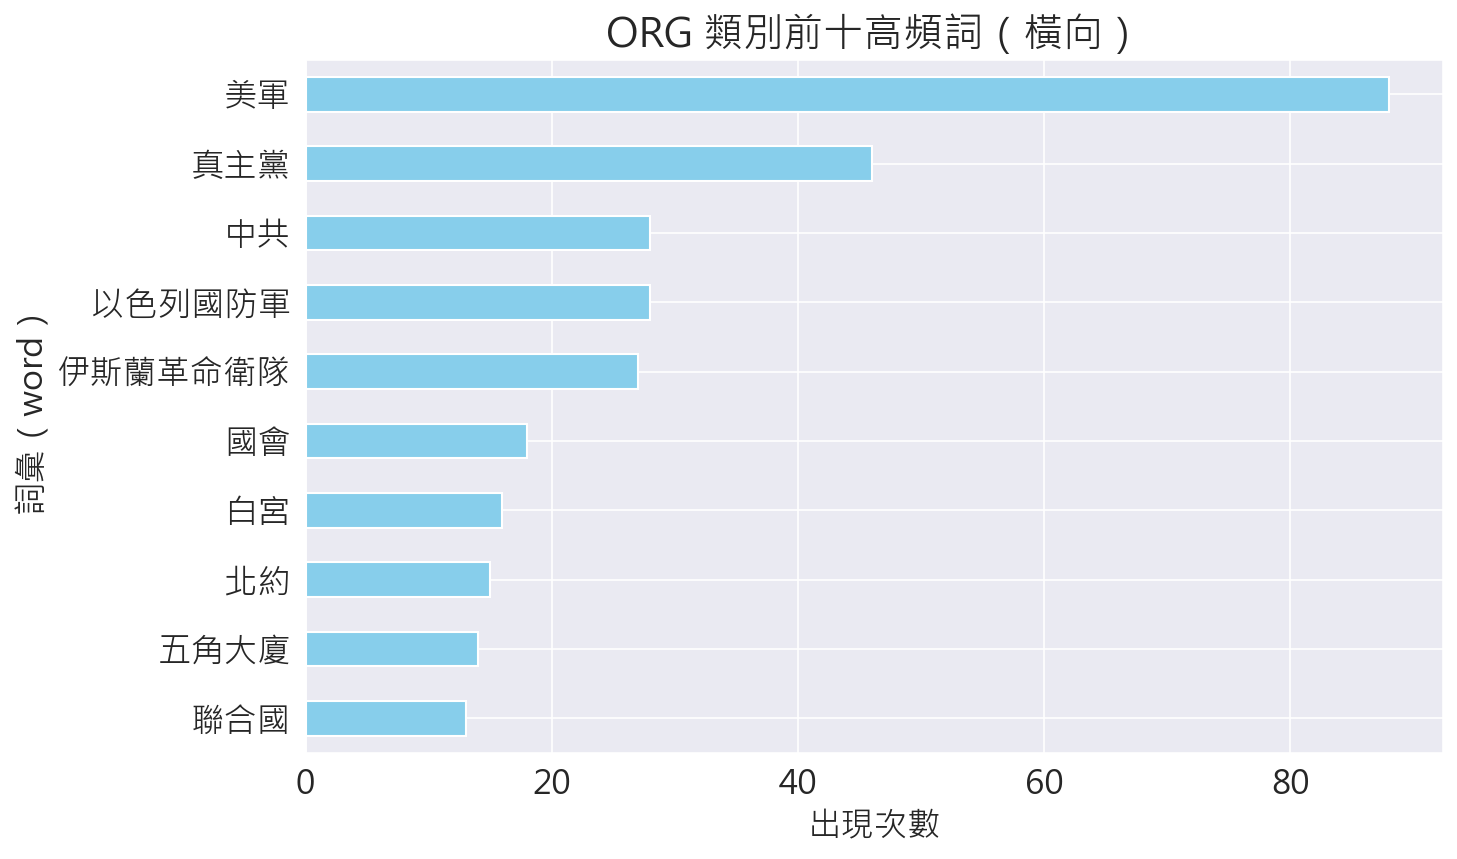

,count
word,
美軍,88
真主黨,46
中共,28
以色列國防軍,28
伊斯蘭革命衛隊,27
國會,18
白宮,16
北約,15
五角大廈,14


In [52]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

top_org_path = TABLE_DIR / "top_org_words.pkl"
top_org_fig_path = FIGURE_DIR / "top_org_words.png"

if top_org_path.exists():
    print(f"已找到 ORG 高頻詞表格，直接讀取：{top_org_path}")
    top_org_words = load_pickle(top_org_path)
else:
    # 統計 ORG 類別中出現頻率最高的前 10 個詞。
    top_org_words = (
        entities_df[entities_df["ner"] == "ORG"]["word"]
        .value_counts()
        .head(10)
    )
    save_pickle(top_org_words, top_org_path)
    print(f"ORG 高頻詞表格已儲存：{top_org_path}")

if top_org_fig_path.exists():
    print(f"已找到 ORG 高頻詞圖片，直接讀取：{top_org_fig_path}")
    display(Image(filename=str(top_org_fig_path)))
else:
    # 第一次執行時繪圖並存成 PNG，之後報告可直接取圖使用。
    plt.figure(figsize=(10, 6))
    top_org_words.plot(kind="barh", color="skyblue")
    plt.title("ORG 類別前十高頻詞（橫向）")
    plt.xlabel("出現次數")
    plt.ylabel("詞彙（word）")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(top_org_fig_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"ORG 高頻詞圖片已儲存：{top_org_fig_path}")
    display(Image(filename=str(top_org_fig_path)))

top_org_words.to_frame("count")


**圖表分析：** 這張圖是在看文章中最常被提到的組織。可以看到「美軍」出現最多，代表這批資料裡很多討論都和美國的軍事行動、軍隊部署，或美國是否介入中東局勢有關。除了美軍之外，「伊斯蘭革命衛隊」也很常出現，表示大家也很關注伊朗這邊的重要軍事組織，以及它可能採取的行動和立場。另外，像真主黨和以色列國防軍也有出現在前面，代表這些討論不只是美國和伊朗兩方，而是牽涉到以色列、伊朗相關組織，以及區域武裝勢力之間的衝突關係。


### 功能說明：PERSON 類別前十高頻詞圖

這個儲存格會統計 PERSON 類別中最常出現的前十個人物名稱，並將表格與圖片存入資料夾。下次執行時若已存在檔案，會直接讀取並呈現固定結果。


已找到 PERSON 高頻詞表格，直接讀取：project3_saved_outputs\tables\top_person_words.pkl
已找到 PERSON 高頻詞圖片，直接讀取：project3_saved_outputs\figures\top_person_words.png


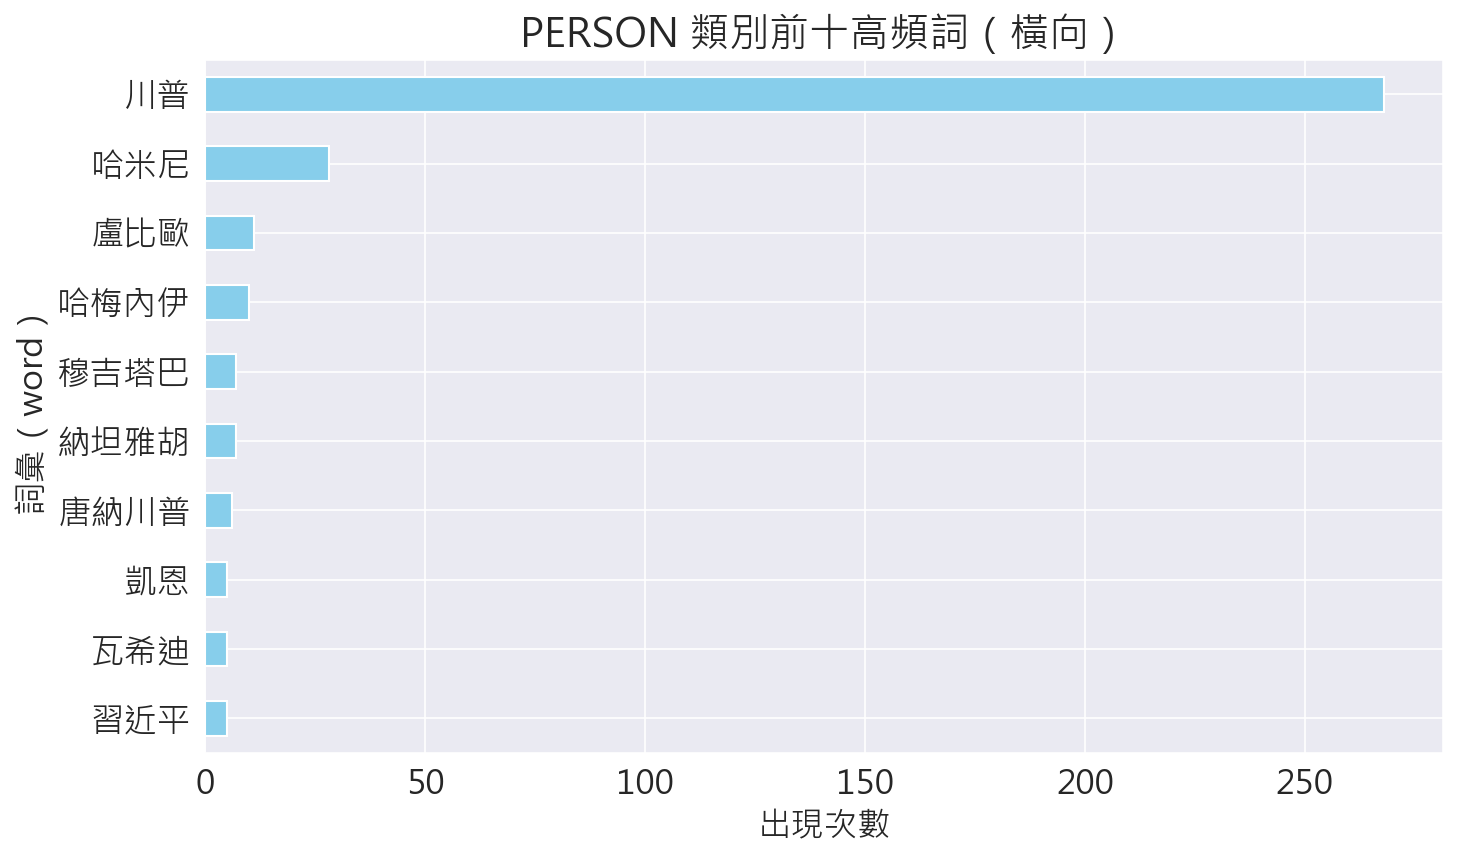

,count
word,
川普,268
哈米尼,28
盧比歐,11
哈梅內伊,10
穆吉塔巴,7
納坦雅胡,7
唐納川普,6
凱恩,5
瓦希迪,5


In [53]:
top_person_path = TABLE_DIR / "top_person_words.pkl"
top_person_fig_path = FIGURE_DIR / "top_person_words.png"

if top_person_path.exists():
    print(f"已找到 PERSON 高頻詞表格，直接讀取：{top_person_path}")
    top_person_words = load_pickle(top_person_path)
else:
    # 統計 PERSON 類別中出現頻率最高的前 10 個詞。
    top_person_words = (
        entities_df[entities_df["ner"] == "PERSON"]["word"]
        .value_counts()
        .head(10)
    )
    save_pickle(top_person_words, top_person_path)
    print(f"PERSON 高頻詞表格已儲存：{top_person_path}")

if top_person_fig_path.exists():
    print(f"已找到 PERSON 高頻詞圖片，直接讀取：{top_person_fig_path}")
    display(Image(filename=str(top_person_fig_path)))
else:
    # 第一次執行時繪圖並存成 PNG，之後報告可直接取圖使用。
    plt.figure(figsize=(10, 6))
    top_person_words.plot(kind="barh", color="skyblue")
    plt.title("PERSON 類別前十高頻詞（橫向）")
    plt.xlabel("出現次數")
    plt.ylabel("詞彙（word）")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(top_person_fig_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"PERSON 高頻詞圖片已儲存：{top_person_fig_path}")
    display(Image(filename=str(top_person_fig_path)))
top_person_words.to_frame("count")


**圖表分析：** 這張圖是在看文章中最常被提到的人物。可以看到「川普」出現次數明顯高於其他人，代表這批資料裡很多討論都和川普的政治動向有關。原因是川普對美國外交政策、對伊朗態度、軍事介入與國際局勢判斷都有很大影響，所以他的發言、決策或立場變化，容易成為討論焦點。


### 功能說明：中文情緒模型推論

這個儲存格使用 `techthiyanes/chinese_sentiment` 模型對每一句話做情緒星等預測。模型輸出為 star 1 到 star 5。


In [54]:
from transformers import pipeline
import pandas as pd
import torch

#情緒模型結果儲存路徑。若已存在，直接讀取，不重新跑模型。
sentiment_results_path = TABLE_DIR / "sentiment_results_df.pkl"

if sentiment_results_path.exists():
    print(f"已找到既有情緒分析結果，直接讀取：{sentiment_results_path}")
    sentiment_results_df = load_pickle(sentiment_results_path)
else:
    model_name = "techthiyanes/chinese_sentiment"

    # 若有 GPU 就使用 GPU；沒有 GPU 時自動改用 CPU
    device = 0 if torch.cuda.is_available() else -1
    sentiment_model = pipeline("sentiment-analysis", model=model_name, device=device)

    # 取出已斷句後的句子，並轉成字串，避免空值或非文字資料造成模型錯誤。
    sentiment_input_df = full_docs.dropna(subset=["sentence"]).reset_index(drop=True)
    sentences = sentiment_input_df["sentence"].astype(str).tolist()

    # batch_size=32，較有效利用 GPU。
    sentiment_raw_outputs = sentiment_model(
        sentences,
        batch_size=32,
        truncation=True
    )
    sentiment_model_outputs_df = pd.DataFrame(sentiment_raw_outputs)

    # 將原始資料與情緒模型結果水平合併。
    sentiment_results_df = pd.concat(
        [sentiment_input_df, sentiment_model_outputs_df],
        axis=1
    )

    # 將情緒模型結果存成 pickle，下次直接從資料夾讀取。
    save_pickle(sentiment_results_df, sentiment_results_path)
    print(f"情緒分析結果已儲存：{sentiment_results_path}")

sentiment_results_df.head()


已找到既有情緒分析結果，直接讀取：project3_saved_outputs\tables\sentiment_results_df.pkl


,artUrl,artTitle,artContent,artCatagory,artDate,title_clean,content_clean,content,sentence,words,word_list_bigrams,label,score
0,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,伊朗更新特別報告,"[伊朗, 更新, 特別, 報告]","[伊朗, 更新, 特別, 報告]",star 5,0.356191
1,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,美國企業研究所旗下的戰爭研究所與關鍵威脅計畫正每日發布更新,"[美國, 企業, 研究所, 旗下, 戰爭, 研究所, 關鍵, 威脅, 計畫, 每日, 發布,...","[美國, 企業, 研究所, 旗下, 戰爭, 研究所, 關鍵, 威脅, 計畫, 每日, 發布,...",star 4,0.605136
2,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,以提供對與伊朗戰爭的分析,"[提供, 伊朗, 戰爭, 分析]","[提供, 伊朗, 戰爭, 分析]",star 4,0.725289
3,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,這些更新聚焦於美國與以色列對伊朗的打擊,"[更新, 聚焦, 美國, 以色列, 伊朗, 打擊]","[更新, 聚焦, 美國, 以色列, 伊朗, 打擊]",star 4,0.606807
4,https://www.ptt.cc/bbs/Military/M.1777180876.A...,[情報] ISW 伊朗更新特別報告，2026年4月25日,https://tinyurl.com/23safa2f\n\n伊朗更新特別報告，2026年...,Military,2026-04-26 13:21:13,伊朗更新特別報告 年月日,伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵威脅計畫 正每日發布更新 ...,伊朗更新特別報告 年月日 伊朗更新特別報告 年月日 美國企業研究所 旗下的戰爭研究所 與關鍵...,以及伊朗與抵抗軸心對這些打擊的回應,"[伊朗, 抵抗, 軸心, 打擊, 回應]","[伊朗, 抵抗_軸心, 打擊, 回應]",star 4,0.640941


### 功能說明：情緒模型的星等分布
情緒(start 1到star 5)：<br>
1. negation<br>
2. Semi-Negation<br>
3. Neutral<br>
4. Semi-positive<br>
5. Positive

In [55]:
# 【修改】只保留情緒星等比例表格，不再產生長條圖
label_check_path = TABLE_DIR / "sentiment_label_ratio_table.pkl"

if label_check_path.exists():
    print(f"已找到情緒星等比例表格，直接讀取：{label_check_path}")
    label_check_df = load_pickle(label_check_path)
else:
    # 【修改】統計模型原始星等分布，並計算各星等比例
    label_distribution = sentiment_results_df["label"].value_counts().sort_index()
    label_ratio = (
        sentiment_results_df["label"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)

    # 【修改】建立只包含 count 與 ratio 的表格
    label_check_df = pd.DataFrame({
        "count": label_distribution,
        "ratio(%)": label_ratio
    })

    save_pickle(label_check_df, label_check_path)
    print(f"情緒星等比例表格已儲存：{label_check_path}")

# 顯示星等比例表格
label_check_df

已找到情緒星等比例表格，直接讀取：project3_saved_outputs\tables\sentiment_label_ratio_table.pkl


,count,ratio(%)
label,,
star 1,10936,9.10
star 2,5089,4.24
star 3,10828,9.01
star 4,73198,60.93
star 5,20078,16.71


### 功能說明：固定抽取 star 4 句子進行人工檢查

這個儲存格只抽取模型判定為 star 4 的句子

因star 4偏多，檢查是否有中性新聞敘述被模型判為偏正面。


In [56]:
star4_samples_path = TABLE_DIR / "star4_samples.pkl"

if star4_samples_path.exists():
    print(f"已找到 star 4 抽樣表格，直接讀取：{star4_samples_path}")
    star4_samples = load_pickle(star4_samples_path)
else:
    star4_df = sentiment_results_df[sentiment_results_df["label"] == "star 4"].copy()
    star4_samples = star4_df.sample(
        n=min(20, len(star4_df)),
        random_state=RANDOM_STATE
    )

    save_pickle(star4_samples, star4_samples_path)
    print(f"star 4 抽樣表格已儲存：{star4_samples_path}")

star4_samples[["sentence", "label", "score"]]


已找到 star 4 抽樣表格，直接讀取：project3_saved_outputs\tables\star4_samples.pkl


,sentence,label,score
21556,被外界解讀為刻意與衝突保持距離的方式,star 4,0.643918
21938,以便未來用來製造核彈,star 4,0.564697
85054,維持民生或者出口貿易的石油也許不足,star 4,0.536512
108368,的數據顯示,star 4,0.302371
38090,伊朗仍保有多達一半的導彈與發射器,star 4,0.504102
4224,各指揮官被賦予更大的自主行動空間,star 4,0.555745
97485,但該進程中仍存在一些障礙需要解決我只能說美國的草包與抽象程度遠遠超乎想像伊斯蘭世界分為遜尼派...,star 4,0.567060
109648,來自臺灣文章網址,star 4,0.495740
52099,阿聯官員強調,star 4,0.380748
13381,來自美國文章網址,star 4,0.368777


**結果分析：** 從 star 4 抽樣結果可以發現，部分被模型判定為偏正面的句子，其實更接近中性新聞敘述。例如「的數據顯示」、「阿聯官員強調」、「來自美國文章網址」、「中央社記者張淑伶周慧盈」等，主要是在提供資料來源、新聞背景或客觀資訊，並沒有明顯正面情緒。因此，模型將這類句子判為 star 4，可能表示該情緒模型在政治與新聞語境中的判斷能力較弱。


### 功能說明：篩選NER句子

這個儲存格會篩選出包含人物、地點、組織或事件相關實體，且句子長度足夠的資料，作為後續 RE 關係分類的輸入。這樣可以較可能排除過短或缺乏實體資訊的句子。


In [57]:
important_signals_path = TABLE_DIR / "important_signals.pkl"

if important_signals_path.exists():
    print(f"已找到 important_signals 表格，直接讀取：{important_signals_path}")
    important_signals = load_pickle(important_signals_path)
else:
    target_entities = ["GPE", "PERSON", "ORG", "LOC", "EVENT"]

    def has_research_value(entities_list):
        # 句子中是否包含目標實體類別
        for entity in entities_list:
            if any(target in entity for target in target_entities):
                return True
        return False

    ner_results["is_signal"] = ner_results["entities"].apply(has_research_value)

    #保留有重要實體、且句子長度大於 10 的句子
    important_signals = ner_results[
        ner_results["is_signal"] & (ner_results["sentence"].str.len() > 10)
    ].copy()

    save_pickle(important_signals, important_signals_path)
    print(f"important_signals 表格已儲存：{important_signals_path}")

important_signals[["sentence", "entities"]].head(10)


已找到 important_signals 表格，直接讀取：project3_saved_outputs\tables\important_signals.pkl


,sentence,entities
0,持續在黎巴嫩南部進行地面行動,"[NerToken(word='黎巴嫩', ner='GPE', idx=(3, 6))]"
2,伊朗政府的回應則是指控志工為以色列與美國從事間諜活動,"[NerToken(word='伊朗', ner='NORP', idx=(0, 2)), ..."
3,美國反恐負責人請辭無法昧著良心支持伊朗戰爭,"[NerToken(word='美國', ner='GPE', idx=(0, 2)), N..."
7,為什麼對委內瑞拉是斬首行動,"[NerToken(word='委內瑞拉', ner='GPE', idx=(4, 8))]"
9,美國只動用不到的軍事力量,"[NerToken(word='美國', ner='GPE', idx=(0, 2))]"
11,來自美國文章網址編輯美國,"[NerToken(word='美國', ner='GPE', idx=(2, 4)), N..."
15,再來美國鑽地飛彈只能炸毀伊朗地下設施的通道設施主體沒有損害,"[NerToken(word='美國', ner='GPE', idx=(2, 4)), N..."
16,伊朗尚未確認是否會派遣談判代表前往伊斯蘭馬巴德,"[NerToken(word='伊朗', ner='GPE', idx=(0, 2)), N..."
17,而是針對美國設施及資產,"[NerToken(word='美國', ner='GPE', idx=(4, 6))]"
18,黎巴嫩政府正尋求將臨時停火延長一個月,"[NerToken(word='黎巴嫩', ner='GPE', idx=(0, 3)), ..."


### 功能說明
這個儲存格使用分類的方式來做 RE 關係分類。作法是先設定幾個可能的關係標籤，例如「軍事衝突與攻擊」、「外交談判與合作」、「經濟制裁與貿易」等，然後讓模型比較每一句話和這些標籤在語意上哪一個最接近。最後，模型會選出最符合句子內容的標籤，並給出信心分數，作為該句子的關係分類結果。

載入 mDeBERTa 的模型，零樣本分類 (Zero-shot)，設定了五個標籤（軍事、外交、經濟、政治、中立新聞)，設定 score > 0.7。

In [58]:
import pandas as pd
import torch
from transformers import pipeline
import re

model_name = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"

device_index = 0 if torch.cuda.is_available() else -1

# 建立 zero-shot classification pipeline
re_model = pipeline(
    "zero-shot-classification",
    model=model_name,
    device=device_index
)

# 自訂 RE 的候選關係類別
candidate_labels = [
    "軍事衝突與攻擊",
    "外交談判與合作",
    "經濟制裁與貿易",
    "政治指控與威脅",
    "中立新聞報導"
]

# 取出前面篩選後的重要句子，作為 RE 分類輸入
sentences = important_signals["sentence"].tolist()

results = re_model(
    sentences,
    candidate_labels=candidate_labels,
    batch_size=32
)

# res['labels'][0] 是模型認為最符合的關係類別
# res['scores'][0] 是該關係類別的信心分數
re_label_df = pd.DataFrame([
    {
        "label": res["labels"][0],
        "score": res["scores"][0]
    }
    for res in results
])

# 將 RE 分類結果接回原本 important_signals
final_df = pd.concat([
    important_signals.reset_index(drop=True),
    re_label_df
], axis=1)

# 只保留信心分數高於 0.7 的結果
filtered_re = final_df[final_df["score"] > 0.7].copy()

def precision_clean(text):
    text_str = str(text)

    # 從 entities 的字串中抓出 word 和 ner 標籤
    found = re.findall(r"word='([^']*)', ner='([^']*)'", text_str)

    # 只保留國家/地區與組織類實體
    valid_entities = [
        word for word, ner in found
        if ner in ["GPE", "ORG"]
    ]

    return valid_entities

df_precision = filtered_re.copy()

# 對每筆資料清理 entities
df_precision["entities_clean"] = df_precision["entities"].apply(precision_clean)

# 根據清理後的實體與 relation label 建立 triplet
def build_triplet_final(row):
    ents = row["entities_clean"]
    label = row["label"]

    # 若句子中有兩個以上實體，就用前兩個實體建立關係三元組
    if len(ents) >= 2:
        return f"({ents[0]}, {label}, {ents[1]})"

    # 若只有一個實體，仍保留該實體，但對象標記為未知
    elif len(ents) == 1:
        return f"({ents[0]}, {label}, 未知對象)"

    # 若沒有可用實體，則無法建立關係
    return "無法構成關係"

df_precision["triplet"] = df_precision.apply(build_triplet_final, axis=1)

final_report = df_precision[["sentence", "label", "triplet", "score"]]

final_report

Device set to use cuda:0


,sentence,label,triplet,score
1,伊朗政府的回應則是指控志工為以色列與美國從事間諜活動,政治指控與威脅,"(以色列, 政治指控與威脅, 美國)",0.988086
3,為什麼對委內瑞拉是斬首行動,軍事衝突與攻擊,"(委內瑞拉, 軍事衝突與攻擊, 未知對象)",0.920841
4,美國只動用不到的軍事力量,軍事衝突與攻擊,"(美國, 軍事衝突與攻擊, 未知對象)",0.837336
6,再來美國鑽地飛彈只能炸毀伊朗地下設施的通道設施主體沒有損害,軍事衝突與攻擊,"(美國, 軍事衝突與攻擊, 伊朗)",0.986251
9,黎巴嫩政府正尋求將臨時停火延長一個月,軍事衝突與攻擊,"(黎巴嫩, 軍事衝突與攻擊, 未知對象)",0.983290
...,...,...,...,...
2354,伊朗在戰爭期間允許部分受伊朗支持的伊拉克民兵在未經伊朗政權批准的情況下發動攻擊,軍事衝突與攻擊,"(伊朗, 軍事衝突與攻擊, 伊朗)",0.996828
2357,該工業城遭到伊朗發射的彈道飛彈攻擊,軍事衝突與攻擊,"(伊朗, 軍事衝突與攻擊, 未知對象)",0.995222
2358,就像三體人對地球人一樣的降維打擊,軍事衝突與攻擊,無法構成關係,0.990660
2367,但伊朗伊斯蘭共和國能夠持續導彈襲擊多久尚不清楚,軍事衝突與攻擊,"(伊朗伊斯蘭共和國, 軍事衝突與攻擊, 未知對象)",0.994348


In [59]:
display(final_report.sort_values(by='score', ascending=False).head(20))

,sentence,label,triplet,score
1759,無人機攻擊的其他目標包括美國海軍第五艦隊在巴林的通訊設備杜拜棕櫚島的豪華飯店,軍事衝突與攻擊,"(美國海軍第五艦隊, 軍事衝突與攻擊, 巴林)",0.998562
2066,四當時的選擇是一軍事升級派遣地面部隊或打擊伊朗基礎設施,軍事衝突與攻擊,"(伊朗, 軍事衝突與攻擊, 未知對象)",0.998500
1097,此役驗證美軍近年大幅投資第代戰機長程精準武器及自殺式無人機的建軍方向正確,軍事衝突與攻擊,"(美軍, 軍事衝突與攻擊, 未知對象)",0.998440
1239,這些攻擊雖然宣稱是針對美軍設施,軍事衝突與攻擊,"(美軍, 軍事衝突與攻擊, 未知對象)",0.998383
1881,這起以及拉梅爾德市附近發生的其他空襲,軍事衝突與攻擊,"(拉梅爾德市, 軍事衝突與攻擊, 未知對象)",0.998271
965,美軍精準打擊已實質性瓦解伊朗軍事反擊能力,軍事衝突與攻擊,"(美軍, 軍事衝突與攻擊, 伊朗)",0.998186
1118,戰爭結果都被美軍打到不要不要的,軍事衝突與攻擊,"(美軍, 軍事衝突與攻擊, 未知對象)",0.998155
1662,反而恐怖攻擊軸心美以越來越後繼乏力了,軍事衝突與攻擊,"(美, 軍事衝突與攻擊, 以)",0.998151
1764,例如小艇撞上油輪無人機突破波斯灣防禦或對飯店與石油設施發動攻擊,軍事衝突與攻擊,無法構成關係,0.997984
1156,轟炸機與戰機倫敦大學瑪麗皇后學院講師奈馬克指出,軍事衝突與攻擊,"(倫敦大學瑪麗皇后學院, 軍事衝突與攻擊, 未知對象)",0.997950


結果分析：
這些句子會被分到「軍事衝突與攻擊」，主要是因為句中出現「攻擊」、「空襲」、「打擊」、「無人機」、「導彈」、「美軍」、「伊朗」等軍事相關詞彙，所以模型判斷它們和軍事衝突類別最接近。

不過，部分 triplet 會出現「未知對象」或「無法構成關係」，是因為句子中可能只抓到一個實體，或 NER 沒有抓到足夠的國家、組織，因此無法完整形成「誰和誰發生關係」。

In [60]:
print("--- 各類別筆數統計 ---")
print(final_report['label'].value_counts())

n_samples = 5
all_samples = []

unique_labels = final_report['label'].unique()

for target_label in unique_labels:
    
    subset = final_report[final_report['label'] == target_label]
    
    sample = subset.sample(n=min(len(subset), n_samples), random_state=42)
    
    all_samples.append(sample)

sampled_re = pd.concat(all_samples).reset_index(drop=True)

sampled_re = sampled_re.sort_values(by=['label', 'score'], ascending=[True, False])

print(f"\n--- 各類別隨機抽樣結果 (每類 {n_samples} 筆) ---")
display(sampled_re[['label', 'score', 'sentence']])

--- 各類別筆數統計 ---
label
軍事衝突與攻擊    769
外交談判與合作    102
中立新聞報導      74
政治指控與威脅     66
經濟制裁與貿易     16
Name: count, dtype: int64

--- 各類別隨機抽樣結果 (每類 5 筆) ---


,label,score,sentence
16,中立新聞報導,0.873286,安全與能源消息人士於月日告訴路透社
18,中立新聞報導,0.806242,皮特並不希望這件事被解決
17,中立新聞報導,0.805342,儘管川普週一的演講語氣樂觀
15,中立新聞報導,0.784740,中國媒體關於美國衰落的討論顯著增加
19,中立新聞報導,0.708674,伊朗各地響起了歡呼聲及慶祝活動
10,外交談判與合作,0.963557,阿卜杜勒哈米德先前在月日的講道中呼籲進行擁有充分授權的強力外交
11,外交談判與合作,0.878516,因為他們喜歡高歌和平與四海兄弟情
14,外交談判與合作,0.839953,把台灣提升為跟日韓以色列同等級的盟友
12,外交談判與合作,0.743040,中東各國想玩也可以封鎖年
13,外交談判與合作,0.734998,依賴中東航線的企業開始調整物流路徑


結果分析：
從各類別筆數可以看出，模型最常將句子分類為「軍事衝突與攻擊」，共有 769 筆，明顯高於其他類別。這代表資料內容主要集中在攻擊、戰爭、軍事行動、無人機、導彈、美軍與伊朗等衝突相關主題。

從隨機抽樣結果來看，分類大致符合句子內容。例如，提到「攻擊」、「戰爭」、「襲擊」的句子多被分到軍事衝突；提到「指責」、「暗殺」、「威脅」的句子則被分到政治指控與威脅；提到「關稅」、「石油進口」、「賣油路線」的句子則被分到經濟制裁與貿易。

## Text Clustering


In [61]:
!pip install sentence_transformers
!pip install ckip_transformers
!pip install bertopic
!pip install bertopic
from transformers import BertTokenizerFast, AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [64]:
# 中文文章
docs_zh = full_docs['sentence'].tolist()[:500]

# 設定繁體中文詞庫
jieba.set_dictionary('../dict/dict.txt')

# 新增 stopwords
with open('../dict/stopwords.txt',encoding="utf-8") as f:
    stopwords = [line.strip() for line in f.readlines()]

# 設定中文 embedding model
bert_sentence_model = SentenceTransformer("google-bert/bert-base-chinese")

# 將中文文章轉換為 embedding
embeddings = bert_sentence_model.encode(docs_zh, show_progress_bar=True)

# 定義不同 clustering layer 所要使用的模型與方法（就用 default 的 HDBSCAN）
hdbscan_model = HDBSCAN(min_cluster_size=15,
            min_samples=4,
            metric='euclidean',
            cluster_selection_method='eom')

# 定義一個適合中文的分詞函數
def tokenize_zh(text):
    words = jieba.lcut(text)
    return words

# 建立一個使用 jieba 分詞的 CountVectorizer
jieba_vectorizer = CountVectorizer(tokenizer=tokenize_zh, stop_words=stopwords, analyzer='word', token_pattern=u"(?u)\\b\\w+\\b")

# 使用 BERTopic 進行主題模型建立
zh_topic_model = BERTopic(embedding_model=bert_sentence_model, vectorizer_model=jieba_vectorizer,hdbscan_model=hdbscan_model, verbose=True, top_n_words=30)
topics, probs = zh_topic_model.fit_transform(docs_zh, embeddings)

zh_topic_model.get_topic_info()

Batches: 100%|██████████| 16/16 [00:00<00:00, 44.21it/s]
2026-05-18 07:57:59,775 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 07:58:00,128 - BERTopic - Dimensionality - Completed ✓
2026-05-18 07:58:00,129 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 07:58:00,142 - BERTopic - Cluster - Completed ✓
2026-05-18 07:58:00,145 - BERTopic - Representation - Fine-tuning topics using representation models.
Building prefix dict from c:\Users\bread\Desktop\Social_Network_Analysis_Group_3_work3\dict\dict.txt ...
Loading model from cache C:\Users\bread\AppData\Local\Temp\jieba.u29c6865baf782012cab1b9b4ce7bac9b.cache
Loading model cost 0.499 seconds.
Prefix dict has been built successfully.
2026-05-18 07:58:00,701 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,93,-1_ _日_川普_月,"[ , 日, 川普, 月, 時, 美國, 坊, 臺灣, 網址, 文章, 站批, 踢踢, 發信...","[發信站批踢踢實業坊, 美國總統唐納川普也於月日宣布, 美國總統唐納川普於月日告訴記者]"
1,0,160,0_ _以色列_伊朗_攻擊,"[ , 以色列, 伊朗, 攻擊, 真主黨, 無人機, 美軍, 黎巴嫩, 美國, 能力, 日,...","[真主黨可能正在對以色列北部無人居住地區及黎巴嫩南部的以色列部隊發動較小規模的攻擊, 其於月..."
2,1,63,1_ _瓦希迪_務實派_體制,"[ , 瓦希迪, 務實派, 體制, 立場, 政權, 彈性, 缺乏, 談判, 巴夫, 決策, ...","[務實派官員可能會繼續主張採取更具彈性的做法, 試圖將政權推向更具彈性的談判立場, 顯示溫和..."
3,2,46,2_談判_伊朗_代表團_,"[談判, 伊朗, 代表團, , 美國, 進行, 立場, 行程, 川普, 之間, 前往, 會...","[美國總統唐納川普因伊朗的談判立場未變, 由於伊朗的談判立場未變, 是因為伊朗在談判上的立場]"
4,3,31,3_ _重點_補充_表示,"[ , 重點, 補充, 表示, 說, 摘要, 稱, 重大, 報告, 一致, 評估, 回應, ...","[萊維特補充說, 侯賽尼補充說, 補充說]"
5,4,30,4_伊朗_風險_ _看到,"[伊朗, 風險, , 看到, 衝突, 戰爭, 接受, 爆發, 億美, 希望, 面臨, 重新...","[這一策略接受戰爭可能重啟的風險, 瓦希迪也更願意承受與美國重新爆發衝突的風險, 瓦希迪也更..."
6,5,29,5_圈子_核心_指揮官_瓦希迪及,"[圈子, 核心, 指揮官, 瓦希迪及, 派系, 巴夫, 加利, 衛隊, 準將, 強硬派, 穆...","[伊朗伊斯蘭革命衛隊指揮官準將艾哈邁德瓦希迪及其核心圈子, 由於伊斯蘭革命衛隊指揮官少將艾哈..."
7,6,27,6_科夫_格齊_阿拉_巴基斯坦,"[科夫, 格齊, 阿拉, 巴基斯坦, 許納, 堡, 庫, 伊斯蘭, 威特, 日, 月, 前往...","[伊朗外交部長阿巴斯阿拉格齊於月日在巴基斯坦伊斯蘭堡會見巴基斯坦高級官員, 取消了美國中東特..."
8,7,21,7_消息_媒體_告訴_一名,"[消息, 媒體, 告訴, 一名, 西方, 來源, 具名, 未, 官員, 報導, 人士, 稱,...","[消息人士告訴西方媒體, 以及巴基斯坦消息來源和一名未具名向西方媒體發言的伊朗消息來源, 巴..."


In [65]:
zh_topic_model.visualize_topics()

In [66]:
# 估算每個文件對BERTopic每個主題的機率分布
topic_distr, _ = zh_topic_model.approximate_distribution(docs_zh)

100%|██████████| 1/1 [00:00<00:00,  7.65it/s]


In [67]:
# 以第7個文件為例，列出這份文件對每個主題的機率分布
zh_topic_model.visualize_distribution(topic_distr[7])

In [68]:
# 列出主題的代表詞和其對應的權重
zh_topic_model.get_topic(2)

[('談判', np.float64(0.15829638513873978)),
 ('伊朗', np.float64(0.1259846989669449)),
 ('代表團', np.float64(0.07791660304103577)),
 (' ', np.float64(0.07692597354993794)),
 ('美國', np.float64(0.06780721574438048)),
 ('進行', np.float64(0.059736209679004955)),
 ('立場', np.float64(0.05723779185079136)),
 ('行程', np.float64(0.047389925847442414)),
 ('川普', np.float64(0.045090868857190436)),
 ('之間', np.float64(0.042951137510732006)),
 ('前往', np.float64(0.04180339000863872)),
 ('會談', np.float64(0.04180339000863872)),
 ('達成', np.float64(0.041275141765354)),
 ('派', np.float64(0.03889103356677596)),
 ('退出', np.float64(0.03889103356677596)),
 ('獨立', np.float64(0.03704619711349539)),
 ('媒體', np.float64(0.03607269508575235)),
 ('團隊', np.float64(0.03554244438558181)),
 ('權力', np.float64(0.03427405596092729)),
 ('美伊', np.float64(0.03317792685419601)),
 ('缺乏', np.float64(0.03221335313304901)),
 ('偏低', np.float64(0.029762307810388917)),
 ('前景', np.float64(0.029762307810388917)),
 ('另有', np.float64(0.02976230781

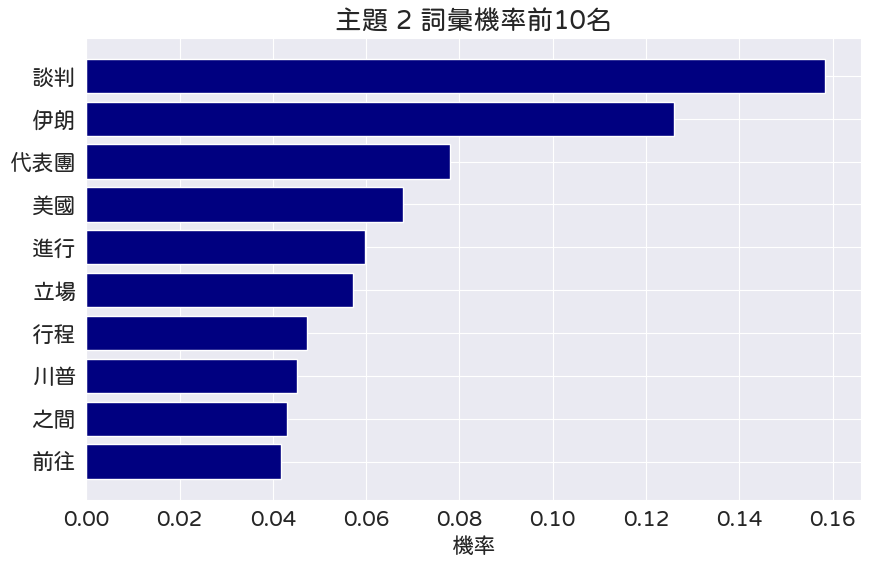

In [69]:
import pandas as pd
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# === 新增的設定：下載並套用中文字型 ===
# 1. 從開源字型庫下載繁體中文字型檔 (.ttf)
font_url = 'https://github.com/justfont/open-huninn-font/raw/master/font/jf-openhuninn-2.0.ttf'
urllib.request.urlretrieve(font_url, 'custom_font.ttf')

# 2. 將字型加入 matplotlib 系統中
fm.fontManager.addfont('custom_font.ttf')
plt.rcParams['font.sans-serif'] = ['jf-openhuninn-2.0'] # 指定使用剛剛下載的字型
plt.rcParams['axes.unicode_minus'] = False              # 避免座標軸的負號變成方塊
# ====================================


# 視覺化顯示主題-詞彙分佈
topic_n = 2
data = zh_topic_model.get_topic(topic_n)

# 轉換為DataFrame
df = pd.DataFrame(data, columns=['word', 'prob'])
df = df[df['word'] != ' ']

# 根據prob排序並選出前10名
top_10 = df.sort_values('prob', ascending=False).head(10)

# 畫出長條圖
plt.figure(figsize=(10,6))
plt.barh(top_10['word'], top_10['prob'], color='navy')
plt.xlabel('機率')
plt.title(f'主題 {topic_n} 詞彙機率前10名')
plt.gca().invert_yaxis()
plt.show()

### 用模型進行主題標籤的調整

In [70]:
from bertopic.representation import KeyBERTInspired
# KeyBERT
keybert = KeyBERTInspired()

# 設定HDBscan模型
hdbscan_model = HDBSCAN(min_cluster_size=5, min_samples=30)

# 定義我們要用到的representation model
representation_model = {
    "KeyBERT": keybert,
}

In [71]:
# 建立BERTopic模型
representation_topic_model = BERTopic(
  # Sub-models
  embedding_model=bert_sentence_model,
  vectorizer_model=jieba_vectorizer,
  # 設定Representation model
  representation_model=representation_model,
  # Hyperparameters
  top_n_words=30,
  verbose=True
)

# Train model
topics, probs = representation_topic_model.fit_transform(docs_zh, embeddings)

2026-05-18 08:02:26,353 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-18 08:02:26,708 - BERTopic - Dimensionality - Completed ✓
2026-05-18 08:02:26,709 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-18 08:02:26,727 - BERTopic - Cluster - Completed ✓
2026-05-18 08:02:26,730 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-18 08:02:27,138 - BERTopic - Representation - Completed ✓


In [72]:
# 觀察KeyBERT微調後的主題表示
representation_topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,Representative_Docs
0,-1,11,-1_撰寫_本文_時_生效,"[撰寫, 本文, 時, 生效, 自月, 日, , 月, 停火, 到期日, 再度, 下旬, ...","[到期日, 撰寫, 本文, 截點, 近期, 自上次, 資料, 原定, 媒體, 自月]","[但截至本文撰寫時, 截至本文撰寫時, 但截至本文撰寫時]"
1,0,317,0_ _伊朗_談判_美國,"[ , 伊朗, 談判, 美國, 日, 月, 官員, 巴基斯坦, 阿拉, 格齊, 巴夫, 伊斯...","[艾哈邁德, 巴基斯坦, 阿巴斯, 瓦希迪及, 阿拉, 伊斯蘭, 指揮官, 影響力, 瓦希迪...","[是因為伊朗在談判上的立場, 儘管他在月日和日於伊斯蘭堡舉行的第一輪談判中曾率領伊朗代表團,..."
2,1,161,1_ _以色列_伊朗_攻擊,"[ , 以色列, 伊朗, 攻擊, 真主黨, 美國, 無人機, 美軍, 黎巴嫩, 能力, 日,...","[伊拉克, 大規模, 真主黨, 黎巴嫩, 以色列, 科威特, 無人機, 研究所, 火箭彈, 部隊]","[真主黨可能正在對以色列北部無人居住地區及黎巴嫩南部的以色列部隊發動較小規模的攻擊, 其於月..."
3,2,11,2_站批_網址_臺灣_坊,"[站批, 網址, 臺灣, 坊, 文章, 實業, 踢踢, 發信, 編輯, , 美國, , ,...","[發信, 實業, 站批, 文章, 臺灣, 踢踢, 網址, 編輯, 美國, 坊]","[發信站批踢踢實業坊, 發信站批踢踢實業坊, 發信站批踢踢實業坊]"
